# EDA comparatif - Silver shard 3

Comparaison entre:
- shards/silver_9k_shards/silver_shard_3.csv
- artifacts/silver_shard_3_cleaned/silver_shard_3.corrected.cleaned.csv

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

In [23]:
SOURCE_PATH = Path("shards/silver_9k_shards/silver_shard_3.csv")
CLEANED_PATH = Path("artifacts/silver_shard_3_cleaned/silver_shard_3.corrected.cleaned.csv")

def read_csv_smart(path: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "latin1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

def normalize_series(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

In [24]:
source_df = read_csv_smart(SOURCE_PATH)
cleaned_df = read_csv_smart(CLEANED_PATH)

print(f"Source file: {SOURCE_PATH}")
print(f"Cleaned file: {CLEANED_PATH}")
print(f"Source shape: {source_df.shape}")
print(f"Cleaned shape: {cleaned_df.shape}")

print("\nSource columns:")
print(source_df.columns.tolist())
print("\nCleaned columns:")
print(cleaned_df.columns.tolist())

Source file: shards\silver_9k_shards\silver_shard_3.csv
Cleaned file: artifacts\silver_shard_3_cleaned\silver_shard_3.corrected.cleaned.csv
Source shape: (9005, 9)
Cleaned shape: (8830, 9)

Source columns:
['data_id', 'id', 'classe', 'darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic', 'english_word_count', 'status']

Cleaned columns:
['data_id', 'id', 'classe', 'darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic', 'english_word_count', 'status']


In [25]:
def summarize_dataset(df: pd.DataFrame, name: str) -> dict:
    summary = {
        "dataset": name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "duplicated_rows": int(df.duplicated().sum()),
    }
    if "data_id" in df.columns:
        summary["unique_data_id"] = int(df["data_id"].nunique(dropna=True))
        summary["duplicated_data_id"] = int(df["data_id"].duplicated().sum())
    else:
        summary["unique_data_id"] = np.nan
        summary["duplicated_data_id"] = np.nan
    return summary

summary_df = pd.DataFrame([
    summarize_dataset(source_df, "source"),
    summarize_dataset(cleaned_df, "cleaned"),
])
summary_df

,dataset,rows,columns,duplicated_rows,unique_data_id,duplicated_data_id
0,source,9005,9,0,9005,0
1,cleaned,8830,9,0,8830,0


In [26]:
common_cols = sorted(set(source_df.columns) & set(cleaned_df.columns))

missing_table = pd.DataFrame({
    "source_missing": source_df[common_cols].isna().sum(),
    "cleaned_missing": cleaned_df[common_cols].isna().sum(),
})
missing_table["delta_cleaned_minus_source"] = (
    missing_table["cleaned_missing"] - missing_table["source_missing"]
)

print("Missing values (top 20 by absolute delta):")
missing_table.assign(abs_delta=missing_table["delta_cleaned_minus_source"].abs())\
    .sort_values("abs_delta", ascending=False)\
    .drop(columns=["abs_delta"])\
    .head(20)

def status_counts(df: pd.DataFrame, name: str) -> pd.Series:
    if "status" not in df.columns:
        return pd.Series(dtype="int64", name=name)
    s = df["status"].fillna("<NA>").astype(str).value_counts(dropna=False)
    s.name = name
    return s

status_table = pd.concat(
    [status_counts(source_df, "source"), status_counts(cleaned_df, "cleaned")],
    axis=1,
).fillna(0).astype(int)

if not status_table.empty:
    print("\nStatus distribution:")
    display(status_table)
else:
    print("\nStatus column is not present in one or both datasets.")

Missing values (top 20 by absolute delta):

Status distribution:


,source,cleaned
status,,
GENERATED,6801,0
PARTIALLY VALIDATED,2199,0
active,5,0
VALIDATED,0,8830


In [27]:
if "data_id" in source_df.columns and "data_id" in cleaned_df.columns:
    source_ids = set(source_df["data_id"].dropna().astype(str))
    cleaned_ids = set(cleaned_df["data_id"].dropna().astype(str))

    overlap_df = pd.DataFrame({
        "metric": [
            "source_unique_ids",
            "cleaned_unique_ids",
            "intersection_ids",
            "source_only_ids",
            "cleaned_only_ids",
        ],
        "count": [
            len(source_ids),
            len(cleaned_ids),
            len(source_ids & cleaned_ids),
            len(source_ids - cleaned_ids),
            len(cleaned_ids - source_ids),
        ],
    })
    overlap_df
else:
    print("No data_id in one or both datasets; overlap cannot be computed.")

Comparable text columns: ['darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic']


,dataset,column,mean_len,median_len,p95_len,max_len
0,source,darija_arabic,126.386119,132.0,232.0,366
1,source,darija_arabizi,137.162465,144.0,252.0,413
2,source,english,147.885619,154.0,266.0,346
3,source,modern_standard_arabic,142.737701,130.0,229.0,163453
4,cleaned,darija_arabic,101.325821,103.0,196.0,282
5,cleaned,darija_arabizi,112.815855,116.0,212.0,302
6,cleaned,english,100.940883,105.0,192.0,272
7,cleaned,modern_standard_arabic,93.096716,95.0,181.0,267


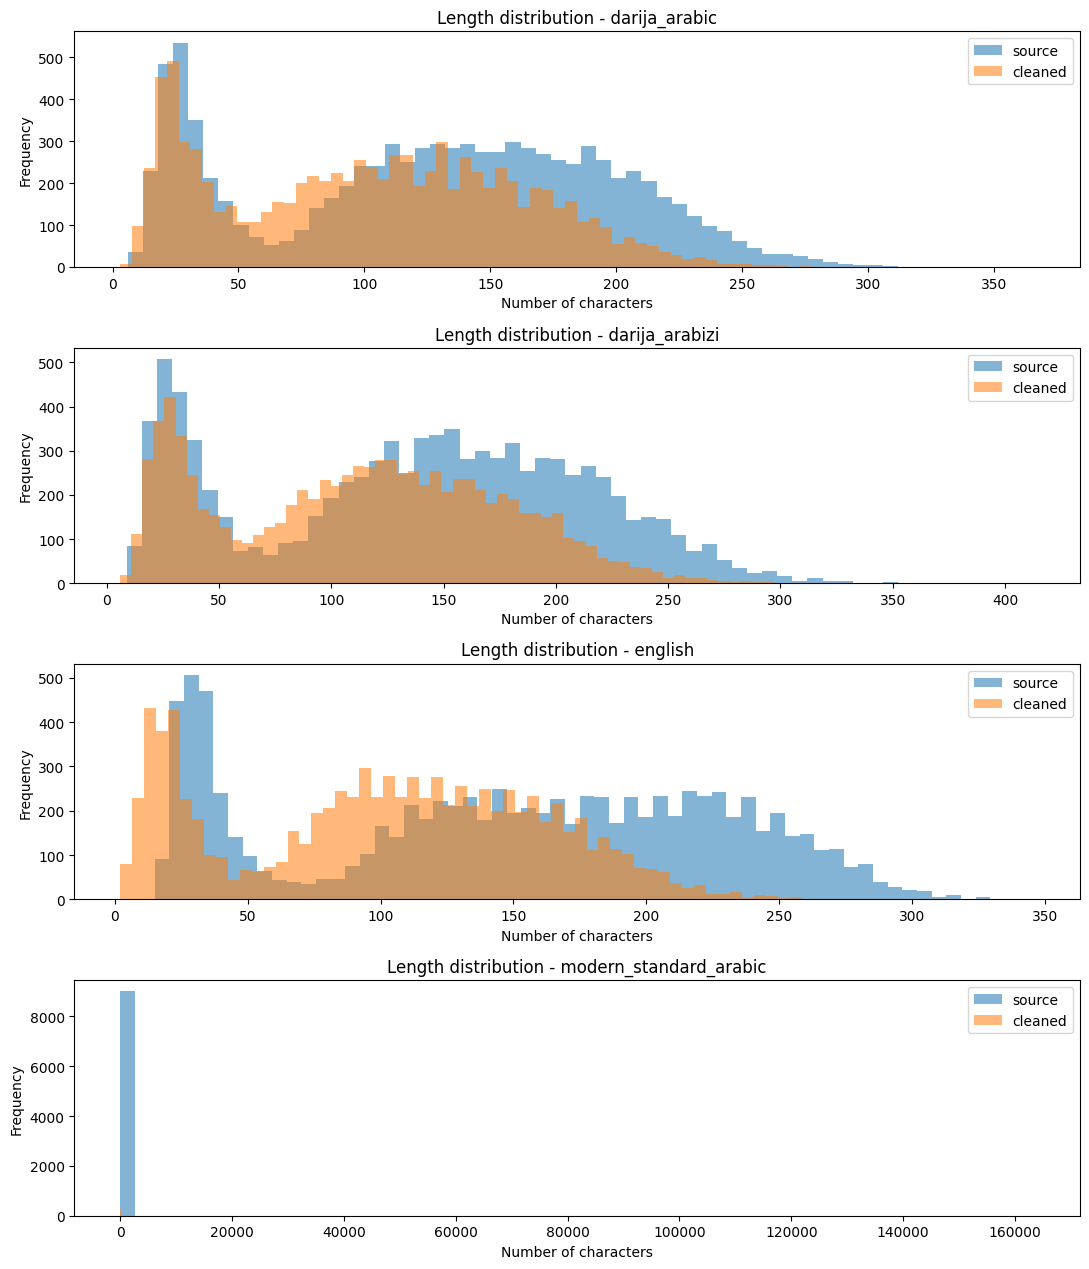

In [28]:
TEXT_COLS = [
    col
    for col in ["darija_arabic", "darija_arabizi", "english", "modern_standard_arabic"]
    if col in source_df.columns and col in cleaned_df.columns
]
print("Comparable text columns:", TEXT_COLS)

def length_stats(df: pd.DataFrame, dataset_name: str, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        lengths = df[col].fillna("").astype(str).str.len()
        rows.append({
            "dataset": dataset_name,
            "column": col,
            "mean_len": float(lengths.mean()),
            "median_len": float(lengths.median()),
            "p95_len": float(lengths.quantile(0.95)),
            "max_len": int(lengths.max() if len(lengths) else 0),
        })
    return pd.DataFrame(rows)

if TEXT_COLS:
    length_df = pd.concat([
        length_stats(source_df, "source", TEXT_COLS),
        length_stats(cleaned_df, "cleaned", TEXT_COLS),
    ], ignore_index=True)
    display(length_df)

    fig, axes = plt.subplots(len(TEXT_COLS), 1, figsize=(11, 3.2 * len(TEXT_COLS)))
    if len(TEXT_COLS) == 1:
        axes = [axes]

    for ax, col in zip(axes, TEXT_COLS):
        source_df[col].fillna("").astype(str).str.len().plot(
            kind="hist", bins=60, alpha=0.55, label="source", ax=ax
        )
        cleaned_df[col].fillna("").astype(str).str.len().plot(
            kind="hist", bins=60, alpha=0.55, label="cleaned", ax=ax
        )
        ax.set_title(f"Length distribution - {col}")
        ax.set_xlabel("Number of characters")
        ax.legend()

    plt.tight_layout()
else:
    print("No common text columns to compare.")

In [29]:
comp = None
join_key = "data_id"

if not TEXT_COLS:
    print("No comparable text columns for diff analysis.")
elif "data_id" in source_df.columns and "data_id" in cleaned_df.columns:
    source_cmp = source_df[["data_id"] + TEXT_COLS].drop_duplicates(subset="data_id", keep="first")
    cleaned_cmp = cleaned_df[["data_id"] + TEXT_COLS].drop_duplicates(subset="data_id", keep="first")
    comp = source_cmp.merge(cleaned_cmp, on="data_id", how="inner", suffixes=("_source", "_cleaned"))
else:
    join_key = "row_index"
    src = source_df[TEXT_COLS].reset_index(drop=True)
    cln = cleaned_df[TEXT_COLS].reset_index(drop=True)
    n = min(len(src), len(cln))
    comp = pd.DataFrame({"row_index": range(n)})
    for col in TEXT_COLS:
        comp[f"{col}_source"] = src[col].iloc[:n].values
        comp[f"{col}_cleaned"] = cln[col].iloc[:n].values

if comp is not None and not comp.empty:
    for col in TEXT_COLS:
        left = normalize_series(comp[f"{col}_source"])
        right = normalize_series(comp[f"{col}_cleaned"])
        comp[f"{col}_changed"] = left.ne(right)

    changes = []
    for col in TEXT_COLS:
        changed_count = int(comp[f"{col}_changed"].sum())
        total = int(len(comp))
        pct = (changed_count / total * 100.0) if total else 0.0
        changes.append({
            "column": col,
            "compared_rows": total,
            "changed_rows": changed_count,
            "change_rate_pct": round(pct, 2),
        })

    change_df = pd.DataFrame(changes).sort_values("change_rate_pct", ascending=False)
    display(change_df)

    overall_changed = int(comp[[f"{col}_changed" for col in TEXT_COLS]].any(axis=1).sum())
    print(f"Rows with at least one changed text field: {overall_changed}/{len(comp)}")
else:
    print("No overlapping rows found for text diff analysis.")

,column,compared_rows,changed_rows,change_rate_pct
2,english,8830,8830,100.00
3,modern_standard_arabic,8830,8809,99.76
0,darija_arabic,8830,8806,99.73
1,darija_arabizi,8830,8427,95.44


Rows with at least one changed text field: 8830/8830


In [30]:
if comp is None or comp.empty:
    print("No comparable rows to preview.")
else:
    row_changed = comp[[f"{col}_changed" for col in TEXT_COLS]].any(axis=1)
    changed_preview = comp.loc[row_changed].copy()

    print(f"Comparable rows: {len(comp)}")
    print(f"Rows changed in >=1 text column: {len(changed_preview)}")

    preview_cols = [join_key]
    for col in TEXT_COLS:
        preview_cols += [f"{col}_source", f"{col}_cleaned", f"{col}_changed"]

    display(changed_preview[preview_cols].head(20))

Comparable rows: 8830
Rows changed in >=1 text column: 8830


,data_id,darija_arabic_source,darija_arabic_cleaned,darija_arabic_changed,darija_arabizi_source,darija_arabizi_cleaned,darija_arabizi_changed,english_source,english_cleaned,english_changed,modern_standard_arabic_source,modern_standard_arabic_cleaned,modern_standard_arabic_changed
0,data73044,واحد الكروب أخور ديال الكورة كاين فباداخوز سمي...,واحد الكروب اخر الكوره كاىن فباداخوز سمىتو باد...,True,wa7ed lkroop akhor dyal lkora kayn f badajoz s...,wa7ed lkroop akhor lkora kayn badajoz smito ba...,True,Another football club based in Badajoz is Bada...,another football club badajoz cf playing terce...,True,نادي كرة قدم آخر مقره في بطليوس هو نادي بطليوس...,نادي كرة قدم اخر باداخوز نادي باداخوز سي يلعب ...,True
1,data73045,برهنّا... باللي من بعد ما يتسالا المخزون ديالن...,برهنا باللى بعد ىتسالا المخزون دىالنا البترول ...,True,Brahenna... balli men ba3d ma itsala lmakhzoun...,brahenna balli ba3d itsala lmakhzoun dyalna lb...,True,We have proved ... that after our stores of oi...,proved stores oil coal exhausted human race re...,True,لقد أثبتنا... أنه بعد استنفاد مخزوناتنا من الن...,لقد اثبتنا استنفاد مخزوناتنا النفط والفحم يمكن...,True
2,data73046,"پيرين، بيرنادوت، ""إعادة الاعتبار لـتيرامينس""، ...",بىرىن برنادوت اعاده الاعتبار لتىرامىنس المجله ...,True,"Pirenne, Bernadotte, ""I3adato al-I3tibar li-Th...",pirin bernadot i3adato i3tibar li teraminis ma...,True,"Perrin , Bernadotte , "" The Rehabilitation of ...",perrin bernadotte rehabilitation theramenes am...,True,"بيرين، برنادوت، ""إعادة تأهيل ثيرامينس""، المجلة...",بيرين برنادوت اعادة الاعتبار لتيرامينس المجلة ...,True
3,data73047,"مانينغ، شاندرا، ""التبدلات اللي طرات فالمواقف د...",مانىنغ شاندرا التبدلات اللى طرات فالمواقف النا...,True,"maning, shandra, ""l-tbddlat li ttrat f-l-mawat...",maning shandra tbddlat li ttrat mawatif n nas ...,True,"Manning , Chandra , "" The Shifting Terrain of ...",manning chandra shifting terrain attitudes tow...,True,"مانينغ، تشاندرا، ""التضاريس المتغيرة للمواقف تج...",مانينغ شاندرا التبدلات حدثت مواقف الناس ابراها...,True
4,data73048,"فالهندية و الأردية، سمية ""سكندر"" اللي جاية من ...",فالهندىه الاردىه سمىه سكندر اللى جاىه الفارسىه...,True,"f lhndiya w l'urdia, smit ""sikandar"" lli jaia ...",lhndiya urdia smit sikandar lli jaia lfarsia k...,True,"In Hindi and Urdu , the name "" Sikandar "" , de...",hindi urdu name sikandar derived persian denot...,True,"في الهندية والأردية، يشير اسم ""إسكندر""، المشتق...",الهندية والاردية يشير اسم اسكندر المشتق الفارس...,True
5,data73049,"نهار خمسطاش شهر تسعود، اللي معروف تا بـ""نهار م...",نهار خمسطاش شهر تسعود اللى معروف تا ب نهار معر...,True,"nhar khamstach chhar tsoud, lli ma3rouf ta b-'...",nhar khamstach chhar tsoud lli ma3rouf ta nhar...,True,"The 15th of September , also known as Battle o...",15th september also known battle britain day a...,True,يُعد الخامس عشر من سبتمبر، المعروف أيضًا بيوم ...,يعد الخامس المعروف بيوم معركة بريطانيا ذكرى سن...,True
6,data73050,جورج دبليو ترويت (1973). خطابات من بول (مكتبة ...,جورج دبلىو تروىت خطابات بول مكتبه جورج دبلىو ت...,True,jorj w. trwit (1973). khobtat mn bol (maktabt ...,jorj trwit khobtat bol maktabt jorj trwit gran...,True,George W. Truett ( 1973 ) . Sermons from Paul ...,george w truett 1973 sermons paul george w tru...,True,جورج دبليو. ترويت (1973). عظات من بول (مكتبة ج...,جورج دبليو ترويت عظات بول مكتبة جورج دبليو ترو...,True
7,data73051,من عام 1848 لـ 1851، ويلسون كان مول الشي و مدي...,عام ل وىلسون كان مول الشىء ومدىر الجورنال بوسط...,True,"mn 3am 1848 l 1851, wilson kan mol chih w mdir...",3am wilson kan mol chi mdir jornal boston repu...,True,From 1848 to 1851 Wilson was the owner and edi...,1848 1851 wilson owner editor boston republica...,True,من عام 1848 إلى عام 1851، كان ويلسون مالكًا ور...,عام ويلسون مالكا ورئيس تحرير صحيفة بوسطن ريباب...,True
8,data73052,پارك ديال الدولة ديال پيتيݣريو مسمي على الجنرا...,بارك الدوله بىتغرو مسمى الجنرال الكونفدرالى ج ...,True,park dyal ldoora dyal pettigrew mesmi 3la ljan...,barak ldawla petigru mesmi ljaneral lkonfeder

## Visualisations additionnelles

- Dashboard comparatif: volumetrie, statuts, classes, longueurs moyennes
- Analyse detaillee: boxplots, histogrammes, taux de changement

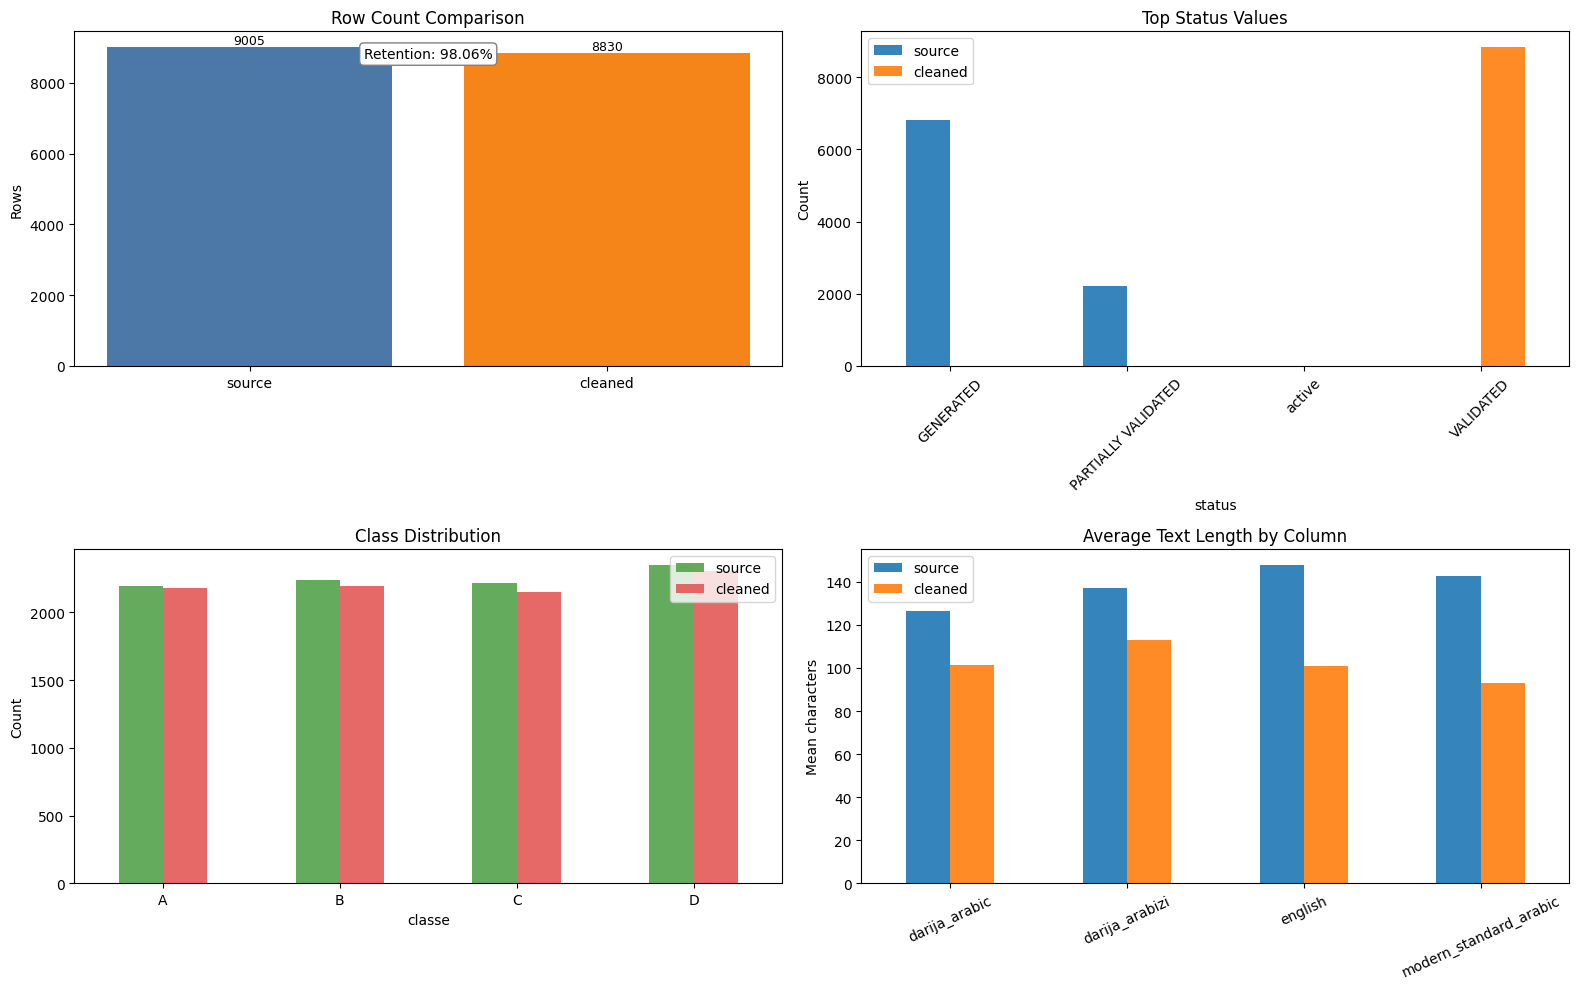

In [31]:
# Visual dashboard: volume, status, class, and average length
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

row_counts = pd.Series({'source': len(source_df), 'cleaned': len(cleaned_df)})
bars = axes[0].bar(row_counts.index, row_counts.values, color=['#4C78A8', '#F58518'])
axes[0].set_title('Row Count Comparison')
axes[0].set_ylabel('Rows')
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
retention = (len(cleaned_df) / len(source_df) * 100.0) if len(source_df) else np.nan
axes[0].text(
    0.5,
    0.92,
    f'Retention: {retention:.2f}%',
    transform=axes[0].transAxes,
    ha='center',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'),
)

if 'status' in source_df.columns and 'status' in cleaned_df.columns:
    src_status = source_df['status'].fillna('<NA>').astype(str).value_counts()
    cln_status = cleaned_df['status'].fillna('<NA>').astype(str).value_counts()
    status_comp = pd.concat(
        [src_status.rename('source'), cln_status.rename('cleaned')], axis=1
    ).fillna(0)
    status_comp = status_comp.sort_values('source', ascending=False).head(12)
    status_comp.plot(kind='bar', ax=axes[1], alpha=0.9)
    axes[1].set_title('Top Status Values')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Status column not found', ha='center', va='center')

if 'classe' in source_df.columns and 'classe' in cleaned_df.columns:
    src_class = source_df['classe'].fillna('<NA>').astype(str).value_counts()
    cln_class = cleaned_df['classe'].fillna('<NA>').astype(str).value_counts()
    class_comp = pd.concat(
        [src_class.rename('source'), cln_class.rename('cleaned')], axis=1
    ).fillna(0)
    class_comp = class_comp.sort_index()
    class_comp.plot(kind='bar', ax=axes[2], alpha=0.9, color=['#54A24B', '#E45756'])
    axes[2].set_title('Class Distribution')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=0)
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'Classe column not found', ha='center', va='center')

if TEXT_COLS:
    mean_len = pd.DataFrame(
        {
            'source': [source_df[c].fillna('').astype(str).str.len().mean() for c in TEXT_COLS],
            'cleaned': [cleaned_df[c].fillna('').astype(str).str.len().mean() for c in TEXT_COLS],
        },
        index=TEXT_COLS,
    )
    mean_len.plot(kind='bar', ax=axes[3], alpha=0.9)
    axes[3].set_title('Average Text Length by Column')
    axes[3].set_ylabel('Mean characters')
    axes[3].tick_params(axis='x', rotation=25)
else:
    axes[3].axis('off')
    axes[3].text(0.5, 0.5, 'No common text columns', ha='center', va='center')

plt.tight_layout()

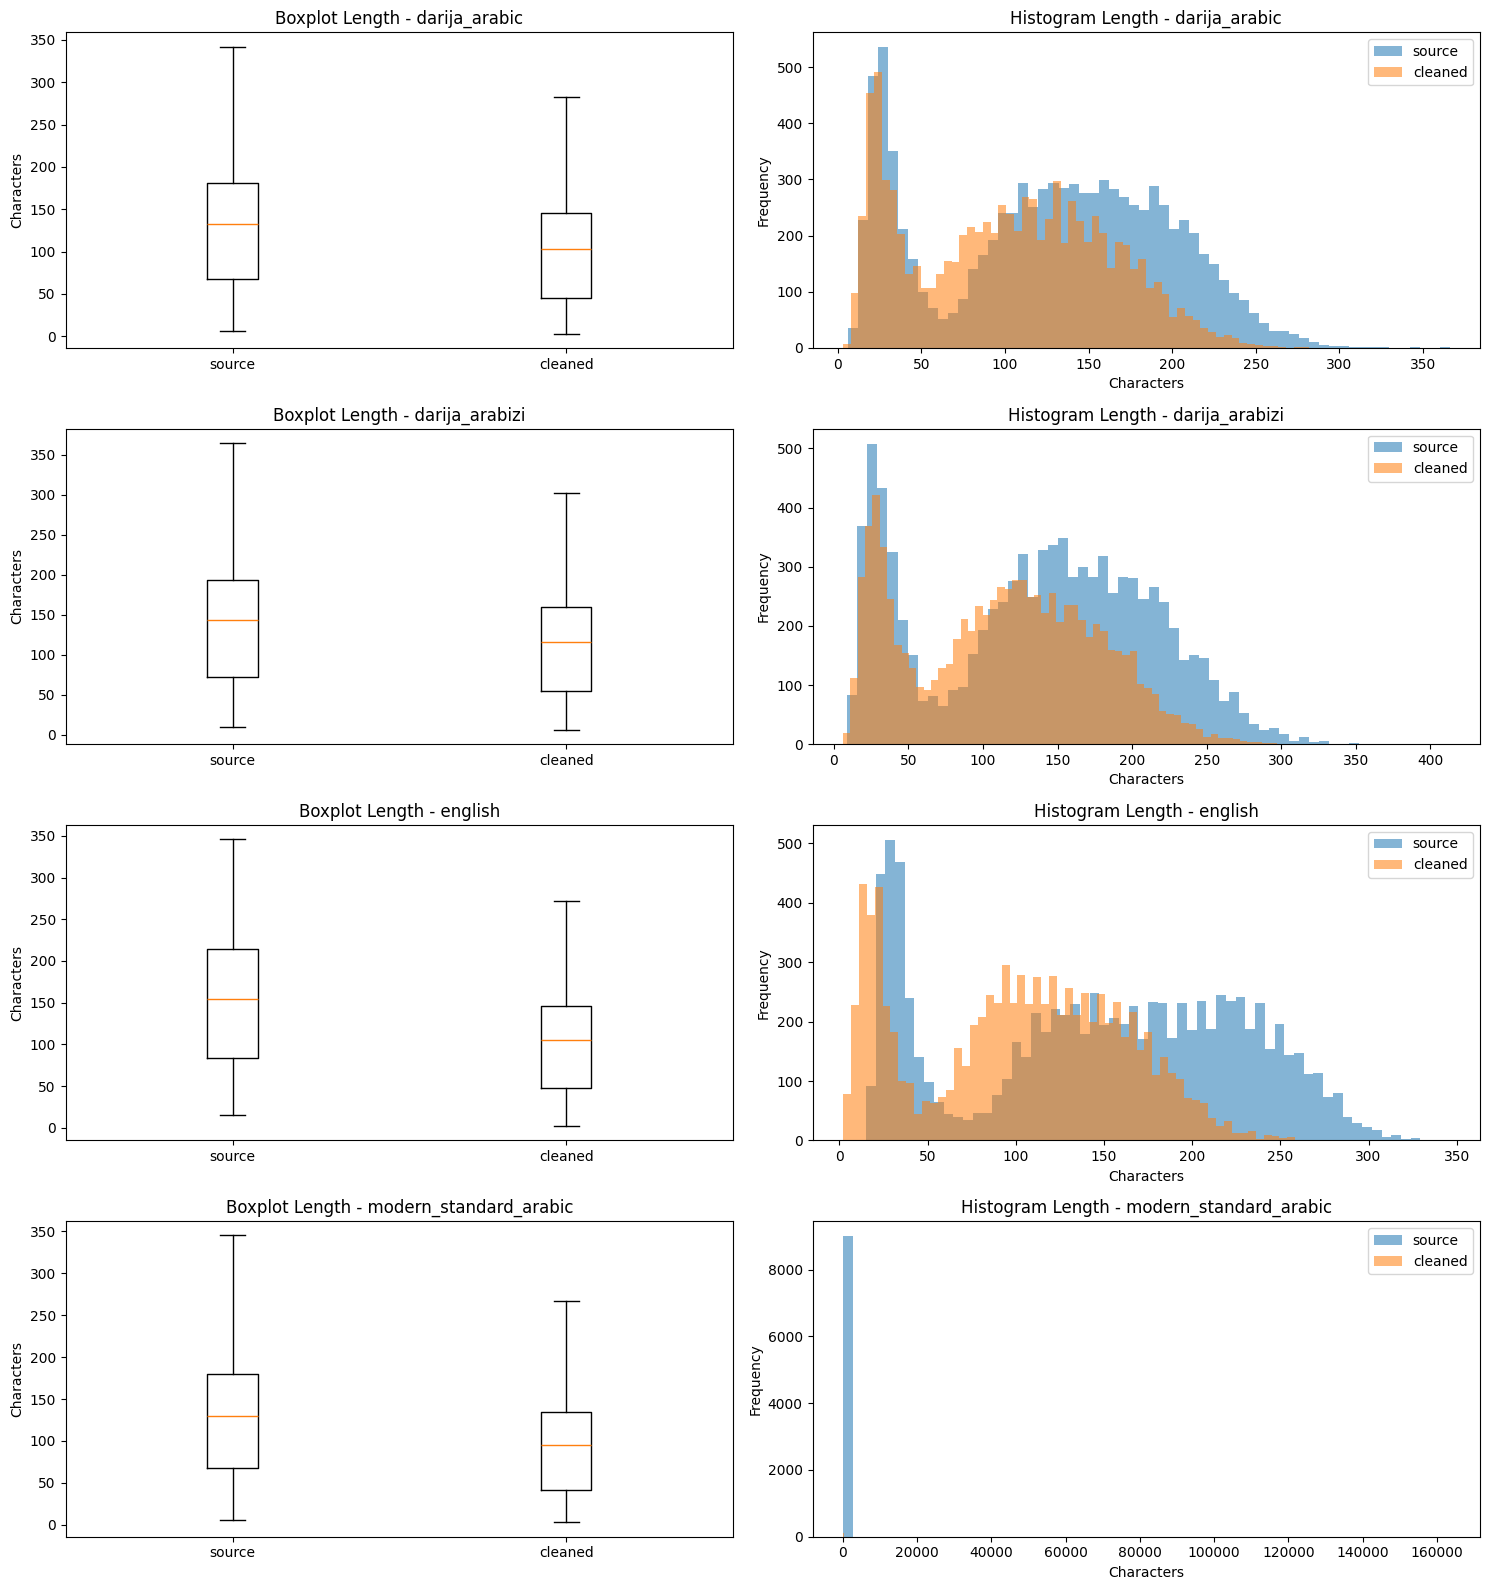

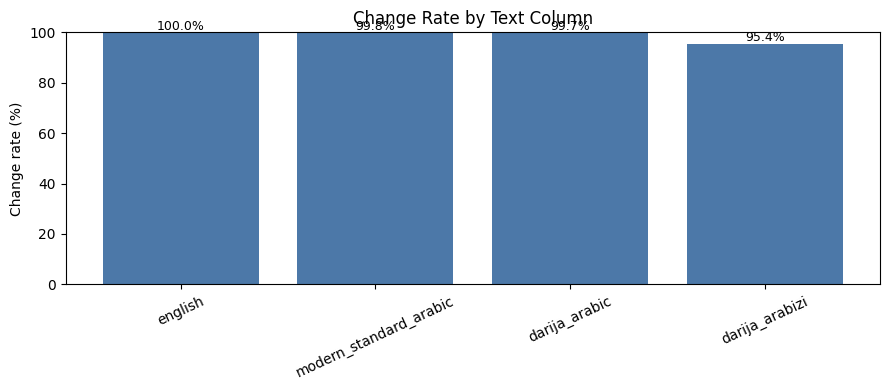

In [32]:
# Deep-dive visuals: boxplots, histogram overlays, and change-rate bars
import numpy as np
import matplotlib.pyplot as plt

if not TEXT_COLS:
    print('No common text columns to visualize.')
else:
    fig, axes = plt.subplots(len(TEXT_COLS), 2, figsize=(15, 4 * len(TEXT_COLS)))
    if len(TEXT_COLS) == 1:
        axes = np.array([axes])

    for i, col in enumerate(TEXT_COLS):
        src_len = source_df[col].fillna('').astype(str).str.len()
        cln_len = cleaned_df[col].fillna('').astype(str).str.len()

        axes[i, 0].boxplot([src_len, cln_len], tick_labels=['source', 'cleaned'], showfliers=False)
        axes[i, 0].set_title(f'Boxplot Length - {col}')
        axes[i, 0].set_ylabel('Characters')

        axes[i, 1].hist(src_len, bins=60, alpha=0.55, label='source')
        axes[i, 1].hist(cln_len, bins=60, alpha=0.55, label='cleaned')
        axes[i, 1].set_title(f'Histogram Length - {col}')
        axes[i, 1].set_xlabel('Characters')
        axes[i, 1].set_ylabel('Frequency')
        axes[i, 1].legend()

    plt.tight_layout()

if 'change_df' in globals() and isinstance(change_df, pd.DataFrame) and not change_df.empty:
    plt.figure(figsize=(9, 4))
    plot_df = change_df.sort_values('change_rate_pct', ascending=False)
    plt.bar(plot_df['column'], plot_df['change_rate_pct'], color='#4C78A8')
    plt.title('Change Rate by Text Column')
    plt.ylabel('Change rate (%)')
    plt.ylim(0, 100)
    plt.xticks(rotation=25)
    for x, y in zip(plot_df['column'], plot_df['change_rate_pct']):
        plt.text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
else:
    print('change_df not found. Run the diff-analysis cell first.')